## Pre-turtorial steps:
### [AGB 100m Dataset Documentation in Earthmover](https://app.earthmover.io/marketplace/69e00e1c21faca8bf36879d2)

## Download conda env using:
`conda env create -f environment.yml`
run this notebook using `aws-agb-env` conda env

# CTrees' Above Ground Biomass Data Access Tutorial — Summary

This tutorial shows how to access, visualize, and analyze global 100m Above Ground Biomass (AGB) data from CTrees  (hosted on the AWS Open Regigstry) using Python. Click the hidden cells to see more details, or get started by running them to install the pip dependencies!

In [ ]:
import geopandas as gpd
import xarray as xr
import rioxarray as rio
import icechunk

In [2]:
# Access data from the IceChunk Repo AWS open Registry 
storage = icechunk.s3_storage(
    bucket="ctrees-agb-100m-global",
    prefix="agb_100m_global",
    region="us-west-2",
    anonymous=True
)

repo = icechunk.Repository.open(storage)

# View FULL AGB Dataset

In [3]:
session = repo.readonly_session(branch="main")
ds = xr.open_zarr(session.store, zarr_format=3, group="aboveground_biomass")
ds

  2026-05-26T20:29:36.334008Z  WARN icechunk::asset_manager: A manifest with 1 chunk references is being loaded into the cache that can only keep 0 references. Consider increasing the size of the manifest cache using the num_chunk_refs field in CachingConfig
    at icechunk/src/asset_manager.rs:381



<xarray.Dataset> Size: 9TB
Dimensions:      (time: 26, y: 202500, x: 405000)
Coordinates:
  * time         (time) datetime64[D] 208B 2000-01-01 2001-01-01 ... 2025-01-01
  * y            (y) float64 2MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0 -90.0
  * x            (x) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B ...
Data variables:
    agb          (time, y, x) float32 9TB ...

## Take a closer look into the "agb" variable

*   The time dimension tells you that this dataset goes from 2000-2025
*   The x & y dimension tell you this is a global dataset
*   The spatial ref tells you the projection system the data is in
*   The attributes tells you the units
*   There is a scale factor of 10


In [4]:
ds.agb

<xarray.DataArray 'agb' (time: 26, y: 202500, x: 405000)> Size: 9TB
[2132325000000 values with dtype=float32]
Coordinates:
  * time         (time) datetime64[D] 208B 2000-01-01 2001-01-01 ... 2025-01-01
  * y            (y) float64 2MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0 -90.0
  * x            (x) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:     Area
    long_name:         Above Ground Biomass
    dtype:             int16
    valid_min:         0
    valid_max:         6000
    units:             Mg ha-1
    agb_scale_factor:  10

# View clipped AGB Dataset

* Let's find a [bounding box](https://bboxfinder.com/) to look closer at the data! Replace the `bbox` below with your choice of WGS84 coordinates

In [5]:
bbox = [-77.124023,-1.318243,-75.454102,-0.357053]

In [6]:
minx, miny, maxx, maxy = bbox

da_clip = ds.agb.sel(
    x=slice(minx, maxx),
    y=slice(maxy, miny),
) / ds.agb.attrs.get("agb_scale_factor")

## Let's plot a few years!

In [7]:
year_one = 2000
year_two = 2025

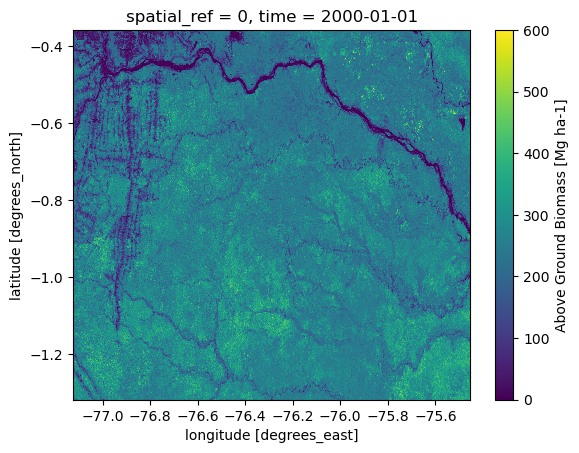

In [8]:
da_clip.sel(time=f"{year_one}-01-01").plot()


2025


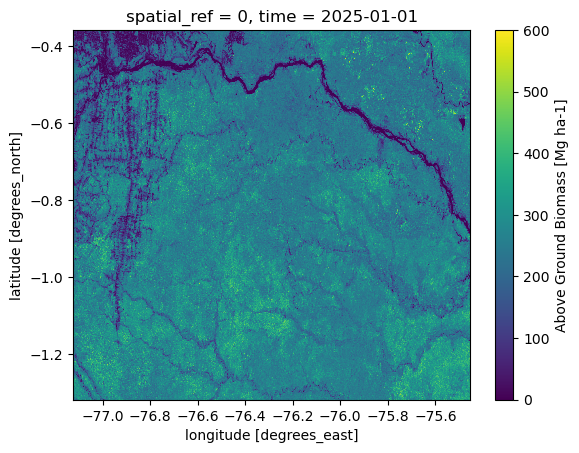

In [9]:
print(year_two)
da_clip.sel(time=f"{year_two}-01-01").plot()

## What if we wanted to save the output as a geotiff?

In [ ]:
da_year = da_clip.sel(time=f"{year_one}-01-01")

da_year.rio.to_raster(f"my_bbox_{year_one}-01-01.tif",
    tiled=True,       # better layout for partial reads
    windowed=True,    # avoids loading everything into memory at once
    compress="LZW",
)

# What if we wanted to plot a geometry?
1. upload geometry to that "files" folder you just downloaded the geotiff from
2. rename "file_name" to your geometry file name, and run the section below!

In [10]:
file_name = "GADM41_USA.5.19_1.geojson"

<Axes: >

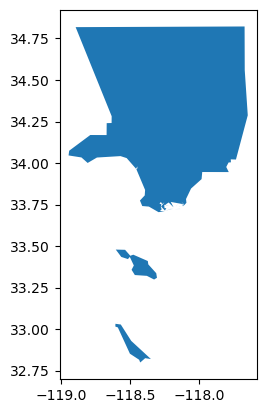

In [11]:
# --- Load geometries ---
gdf = gpd.read_file(file_name)
gdf.geometry.plot()

In [12]:
geom = gdf.geometry
minx, miny, maxx, maxy = geom.total_bounds

# Keep all years, but crop spatially before clipping to the polygon.
da_clip = ds.agb.sel(
    x=slice(minx, maxx),
    y=slice(maxy, miny),
) / ds.agb.attrs.get("agb_scale_factor")

da_masked = da_clip.rio.clip(geom, crs="EPSG:4326", drop=True)

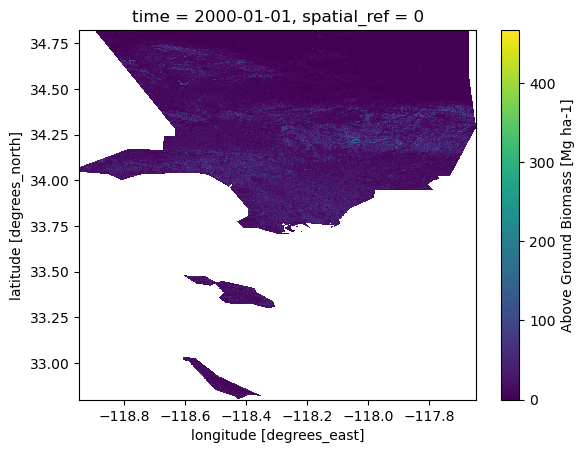

In [13]:
da_masked.sel(time=f"{year_one}-01-01").plot()

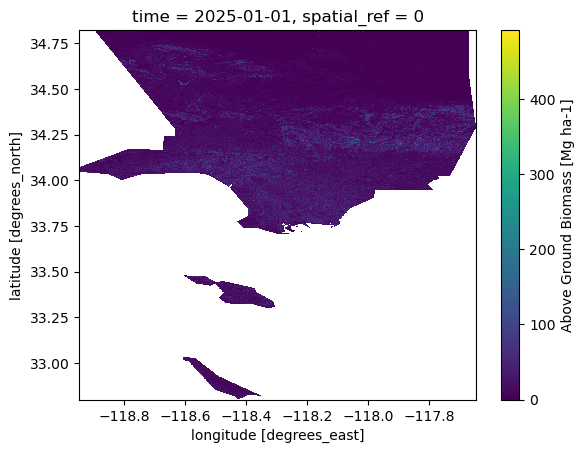

In [14]:
da_masked.sel(time=f"{year_two}-01-01").plot()

## Find AGB values for all years for clipped geometry!

In [15]:
# Define no_data_val and apply masking
no_data_val = -9999

# Apply masking for no_data_val and negatives, then scale
cleaned = da_masked.where(da_masked != no_data_val)  # Mask no_data_val
cleaned = cleaned.where(cleaned > 0, 0)

# Compute total and average AGB for all years at once
stats_df = xr.Dataset(
    data_vars={
        "avg_agb_density": cleaned.mean(dim=("y", "x"), skipna=True).fillna(0),
    }
)

# Convert to pandas DataFrame if needed
stats_df = stats_df.to_dataframe().reset_index()

<Axes: title={'center': 'Average Above Ground Biomass Density'}, xlabel='time'>

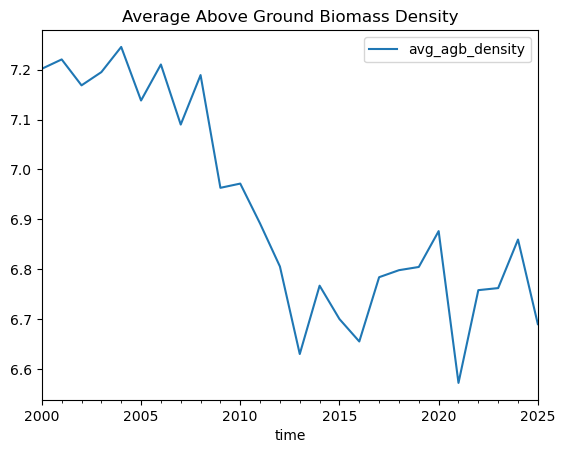

In [16]:
## plot & download time sereis
stats_df.plot(x="time", y="avg_agb_density", title="Average Above Ground Biomass Density")

In [18]:
stats_df.to_csv("average_agb_density_timeseries.csv", index=False)